In [1]:
import numpy as np
import pandas as pd

crime_anal_processed = pd.read_csv("2015_crime_in_seoul_processed.csv", thousands=',', encoding="utf-8")
crime_anal_processed.head()

,Unnamed: 0,살인발생,살인검거,강도발생,강도검거,강간발생,강간검거,절도발생,절도검거,폭력발생,폭력검거,구역
0,서울중부경찰서,2.0,2.0,3.0,2.0,105.0,65.0,1395.0,477.0,1355.0,1170.0,중구
1,서울종로경찰서,3.0,3.0,6.0,5.0,115.0,98.0,1070.0,413.0,1278.0,1070.0,종로구
2,서울남대문경찰서,1.0,0.0,6.0,4.0,65.0,46.0,1153.0,382.0,869.0,794.0,중구
3,서울서대문경찰서,2.0,2.0,5.0,4.0,154.0,124.0,1812.0,738.0,2056.0,1711.0,서대문구
4,서울혜화경찰서,3.0,2.0,5.0,4.0,96.0,63.0,1114.0,424.0,1015.0,861.0,종로구


In [2]:
df = pd.DataFrame({"salary": [20000, 30000, 40000, 50000], 
                   "date": ["2021-01-01", "2021-02-01", "2021-03-01", "2021-04-01"]},
                  index = ["bob", "mike", "bob", "jake"])
df.head()

,salary,date
bob,20000,2021-01-01
mike,30000,2021-02-01
bob,40000,2021-03-01
jake,50000,2021-04-01


In [3]:

df.pivot_table(index=df.index, values=["salary"], aggfunc="sum", fill_value=0)

,salary
bob,60000
jake,50000
mike,30000


In [4]:
df = pd.read_excel("2018_Sales_Total_v2.xlsx")
df.head(10)

,account number,name,sku,quantity,unit price,ext price,date
0,740150,Barton LLC,B1-20000,39,86.69,3380.91,2018-01-01 07:21:51
1,714466,Trantow-Barrows,S2-77896,-1,63.16,-63.16,2018-01-01 10:00:47
2,218895,Kulas Inc,B1-69924,23,90.70,2086.10,2018-01-01 13:24:58
3,307599,"Kassulke, Ondricka and Metz",S1-65481,41,21.05,863.05,2018-01-01 15:05:22
4,412290,Jerde-Hilpert,S2-34077,6,83.21,499.26,2018-01-01 23:26:55
5,714466,Trantow-Barrows,S2-77896,17,87.63,1489.71,2018-01-02 10:07:15
6,218895,Kulas Inc,B1-65551,2,31.10,62.20,2018-01-02 10:57:23
7,729833,Koepp Ltd,S1-30248,8,33.25,266.00,2018-01-03 06:32:11
8,714466,Trantow-Barrows,S1-50961,22,84.09,1849.98,2018-01-03 11:29:02
9,737550,"Fritsch, Russel and Anderson",S2-82423,14,81.92,1146.88,2018-01-03 19:07:37


In [5]:
df.loc[df["name"] == "Barton LLC", :]

,account number,name,sku,quantity,unit price,ext price,date
0,740150,Barton LLC,B1-20000,39,86.69,3380.91,2018-01-01 07:21:51
85,740150,Barton LLC,B1-50809,8,19.60,156.80,2018-01-20 01:48:47
89,740150,Barton LLC,B1-53102,1,68.06,68.06,2018-01-20 13:27:52
94,740150,Barton LLC,S2-16558,2,90.91,181.82,2018-01-21 21:21:01
97,740150,Barton LLC,B1-86481,20,30.41,608.20,2018-01-22 16:33:51
...,...,...,...,...,...,...,...
1332,740150,Barton LLC,S2-77896,30,41.40,1242.00,2018-11-22 05:10:19
1336,740150,Barton LLC,B1-53102,6,33.50,201.00,2018-11-23 00:20:34
1400,740150,Barton LLC,S2-10342,28,77.48,2169.44,2018-12-09 22:48:58
1408,740150,Barton LLC,S2-16558,25,17.65,441.25,2018-12-12 01:41:48


In [6]:
# 이름별로 'ext price' 합계를 집계합니다.
df.pivot_table(index=["name", "sku"], values=["ext price", "quantity", "unit price"], aggfunc=[np.sum, np.mean], fill_value=0).head(10)

C:\Users\taehy\AppData\Local\Temp\ipykernel_13648\1834664800.py:2: FutureWarning: The provided callable <function sum at 0x000001CC7F556520> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.pivot_table(index=["name", "sku"], values=["ext price", "quantity", "unit price"], aggfunc=[np.sum, np.mean], fill_value=0).head(10)
C:\Users\taehy\AppData\Local\Temp\ipykernel_13648\1834664800.py:2: FutureWarning: The provided callable <function mean at 0x000001CC7F557920> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(index=["name", "sku"], values=["ext price", "quantity", "unit price"], aggfunc=[np.sum, np.mean], fill_value=0).head(10)


sum                             mean             \
                    ext price quantity unit price    ext price   quantity   
name       sku                                                              
Barton LLC B1-04202   2433.20       35      69.52  2433.200000  35.000000   
           B1-05914    324.72       24      13.53   324.720000  24.000000   
           B1-20000   7212.11       88     315.69  1803.027500  22.000000   
           B1-33087   4159.97       44     192.83  2079.985000  22.000000   
           B1-33364   4369.19       83     120.24  1456.396667  27.666667   
           B1-38851   6627.93      130     491.00   828.491250  16.250000   
           B1-50809   5087.44      114     160.86  1271.860000  28.500000   
           B1-53102    431.27       10     155.63   143.756667   3.333333   
           B1-53636   3737.59       59     127.15  1868.795000  29.500000   
           B1-65551   4703.54       80     227.57  1175.885000  20.000000   

                                
                    unit price  
name       sku                  
Barton LLC B1-04202  69.520000  
           B1-05914  13.530000  
           B1-20000  78.922500  
           B1-33087  96.415000  
           B1-33364  40.080000  
           B1-38851  61.375000  
           B1-50809  40.215000  
           B1-53102  51.876667  
           B1-53636  63.575000  
           B1-65551  56.892500

In [7]:
crime_anal_processed

,Unnamed: 0,살인발생,살인검거,강도발생,강도검거,강간발생,강간검거,절도발생,절도검거,폭력발생,폭력검거,구역
0,서울중부경찰서,2.0,2.0,3.0,2.0,105.0,65.0,1395.0,477.0,1355.0,1170.0,중구
1,서울종로경찰서,3.0,3.0,6.0,5.0,115.0,98.0,1070.0,413.0,1278.0,1070.0,종로구
2,서울남대문경찰서,1.0,0.0,6.0,4.0,65.0,46.0,1153.0,382.0,869.0,794.0,중구
3,서울서대문경찰서,2.0,2.0,5.0,4.0,154.0,124.0,1812.0,738.0,2056.0,1711.0,서대문구
4,서울혜화경찰서,3.0,2.0,5.0,4.0,96.0,63.0,1114.0,424.0,1015.0,861.0,종로구
5,서울용산경찰서,5.0,5.0,14.0,14.0,194.0,173.0,1557.0,587.0,2050.0,1704.0,용산구
6,서울성북경찰서,2.0,2.0,2.0,1.0,86.0,71.0,953.0,409.0,1194.0,1015.0,성북구
7,서울동대문경찰서,5.0,5.0,13.0,13.0,173.0,146.0,1981.0,814.0,2548.0,2227.0,동대문구
8,서울마포경찰서,8.0,8.0,14.0,10.0,294.0,247.0,2555.0,813.0,2983.0,2519.0,마포구
9,서울영등포경찰서,14.0,12.0,22.0,20.0,295.0,183.0,2964.0,978.0,3572.0,2961.0,영등포구


In [8]:
pivot_crime_anal = pd.pivot_table(crime_anal_processed, index=["구역"], aggfunc=np.sum)
pivot_crime_anal.head(100)

C:\Users\taehy\AppData\Local\Temp\ipykernel_13648\3261515224.py:1: FutureWarning: The provided callable <function sum at 0x000001CC7F556520> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_crime_anal = pd.pivot_table(crime_anal_processed, index=["구역"], aggfunc=np.sum)


,Unnamed: 0,강간검거,강간발생,강도검거,강도발생,살인검거,살인발생,절도검거,절도발생,폭력검거,폭력발생
구역,,,,,,,,,,,
강남구,서울강남경찰서서울수서경찰서,349.0,449.0,18.0,21.0,10.0,13.0,1650.0,3850.0,3705.0,4284.0
강동구,서울강동경찰서,123.0,156.0,8.0,6.0,3.0,4.0,789.0,2366.0,2248.0,2712.0
강북구,서울강북경찰서,126.0,153.0,13.0,14.0,8.0,7.0,618.0,1434.0,2348.0,2649.0
강서구,서울강서경찰서,191.0,262.0,13.0,13.0,8.0,7.0,1260.0,2096.0,2718.0,3207.0
관악구,서울관악경찰서,221.0,320.0,14.0,12.0,8.0,9.0,827.0,2706.0,2642.0,3298.0
광진구,서울동작경찰서서울광진경찰서,359.0,525.0,31.0,23.0,9.0,9.0,1938.0,4891.0,3767.0,4535.0
구로구,서울구로경찰서,164.0,281.0,11.0,15.0,6.0,8.0,889.0,2335.0,2432.0,3007.0
금천구,서울금천경찰서,122.0,151.0,6.0,6.0,4.0,3.0,888.0,1567.0,1776.0,2054.0
노원구,서울노원경찰서,121.0,197.0,7.0,7.0,10.0,10.0,801.0,2193.0,2329.0,2723.0


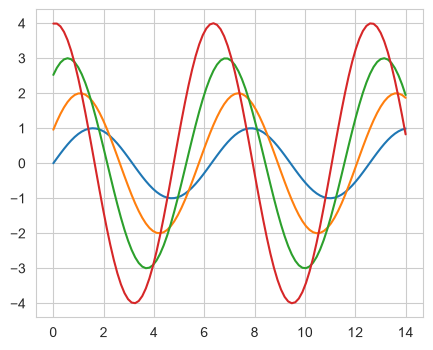

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
x = np.linspace(0, 14, 100)
y1 = np.sin(x)
y2 = 2*np.sin(x + 0.5)
y3 = 3*np.sin(x + 1.0)
y4 = 4*np.sin(x + 1.5)

plt.figure(figsize=(5,4))
plt.plot(x,y1,x,y2,x,y3,x,y4)
plt.show()

In [10]:
tips = sns.load_dataset("tips")
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


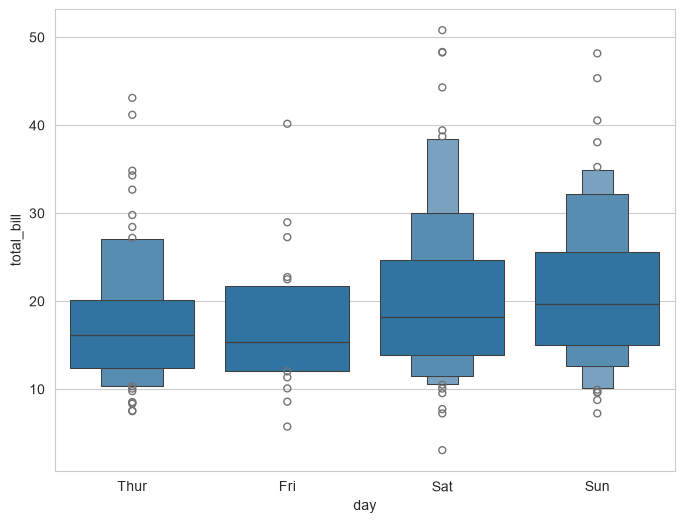

In [11]:
plt.figure(figsize=(8,6))
sns.boxenplot(x="day", y="total_bill", data=tips)
plt.show()

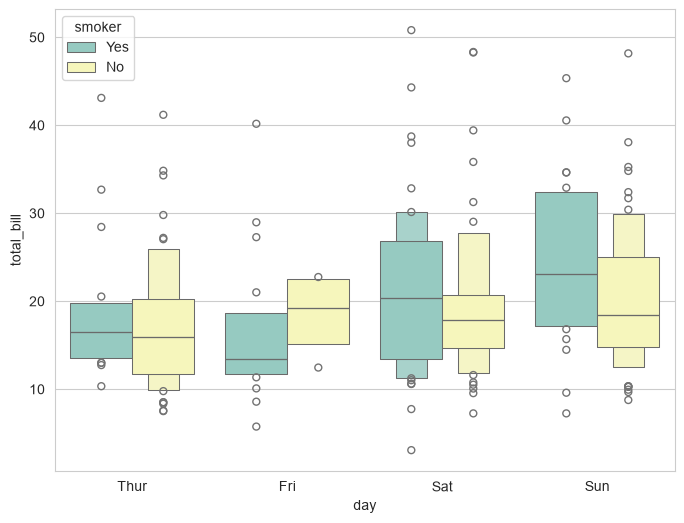

In [12]:
plt.figure(figsize=(8,6))
sns.boxenplot(x="day", y="total_bill", hue="smoker", data=tips, palette="Set3")
plt.show()

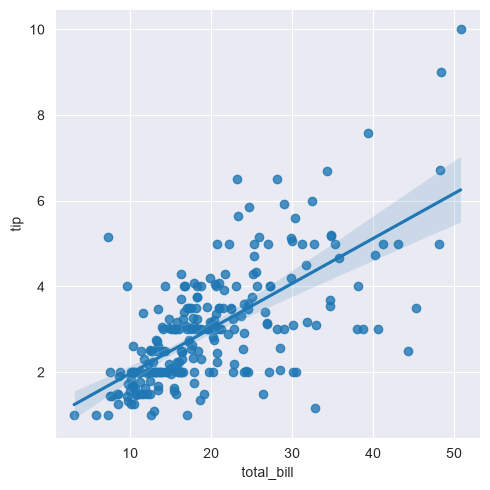

In [13]:
sns.set_style("darkgrid")
sns.lmplot(x="total_bill", y="tip", data=tips)
plt.show()

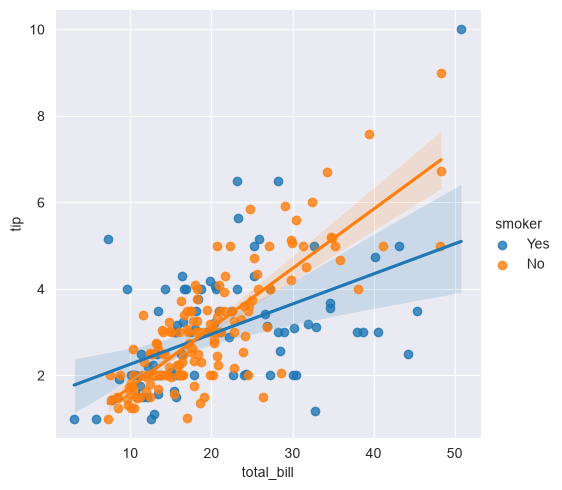

In [14]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips)
plt.show()

In [15]:
flights = sns.load_dataset("flights")
flights.head(5)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [16]:
flights = flights.pivot(index='month', columns='year', values='passengers')
flights.head(10)

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


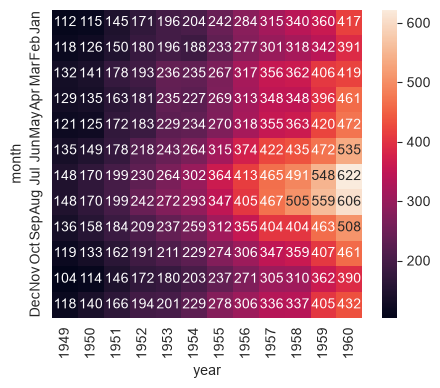

In [18]:
plt.figure(figsize=(5,4))
sns.heatmap(flights, annot=True, fmt="d")
plt.show()

In [25]:
sns.set(style="ticks")
iris = sns.load_dataset("iris")
iris.loc[(iris["sepal_length"] > 5) & (iris["species"] == "virginica")]
iris.loc[(iris.index > 110) & (iris["species"] == "virginica")]
iris.head(10)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


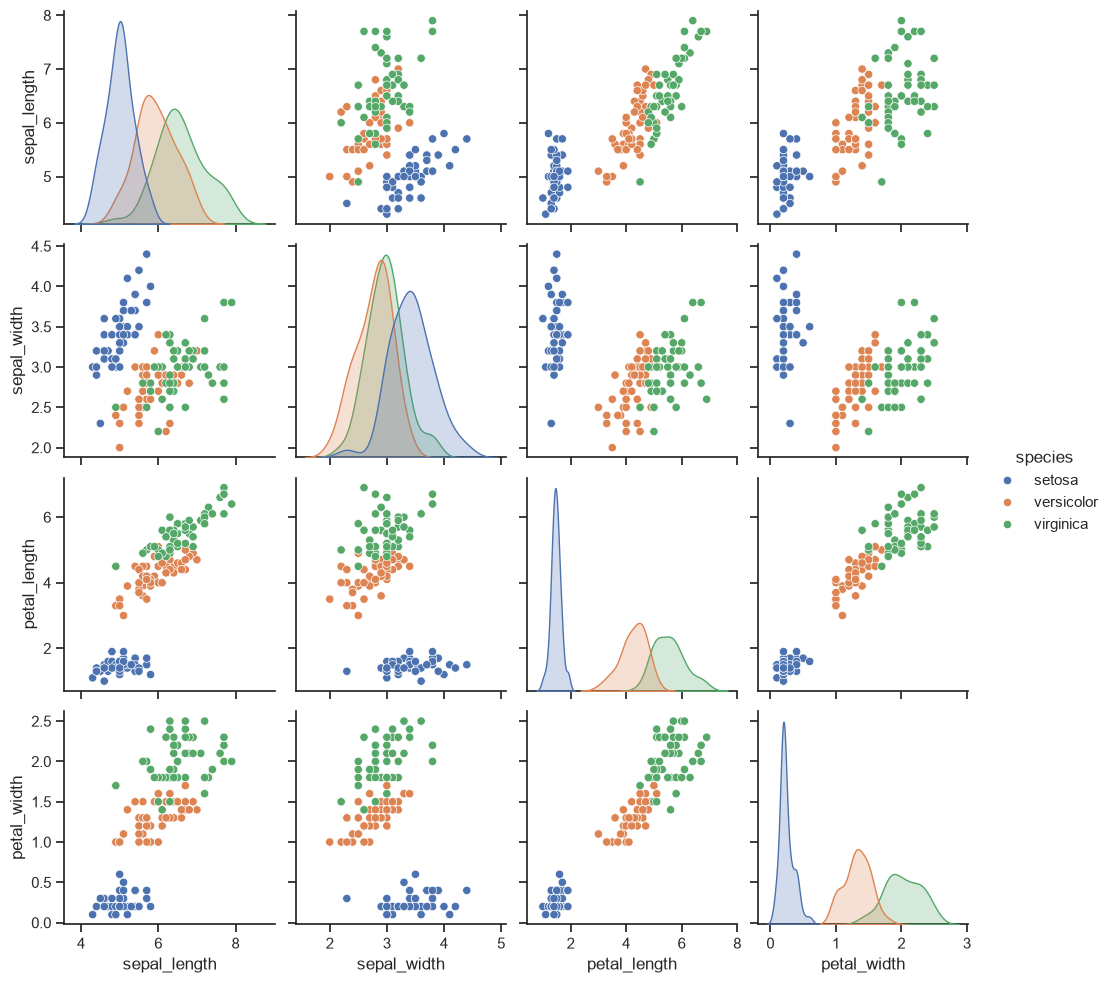

In [26]:
sns.pairplot(iris, hue="species")
plt.show()

c:\Users\taehy\OneDrive\Desktop\Code\LearnPython\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\taehy\OneDrive\Desktop\Code\LearnPython\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\taehy\OneDrive\Desktop\Code\LearnPython\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\taehy\OneDrive\Desktop\Code\LearnPython\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\taehy\OneDrive\Desktop\Code\LearnPython\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\taehy\OneDrive\Desktop\C

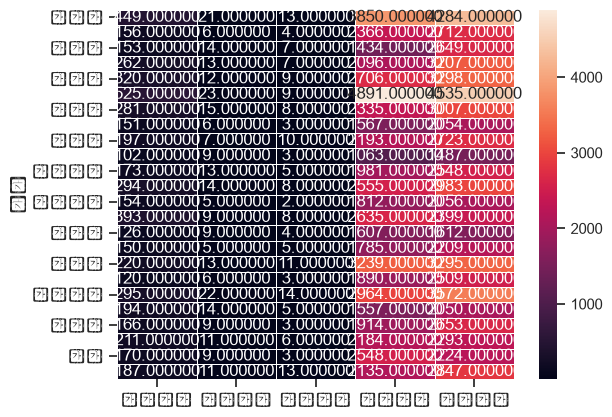

In [30]:
from sklearn import preprocessing

target_col = ["강간발생", "강도발생", "살인발생", "절도발생", "폭력발생"]

sns.heatmap(pivot_crime_anal[target_col], annot=True, fmt='f', linewidths=.5)
plt.show()